E-Commerce Sales Analysis

1. Importing Libraries 

In [ ]:
# 📌 Section 1: Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# Load environment variables (if using .env for credentials)
load_dotenv()

# Visualization Settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("✅ Libraries loaded successfully.")


✅ Libraries loaded successfully.


2. Connecting to Database

In [ ]:
#  Section 2: Connecting to PostgreSQL & Loading Data

# Fetch credentials from environment variables or fallback to manual entry
HOST = os.getenv("DB_HOST", "########")
PORT = os.getenv("DB_PORT", "@@@@")
USER = os.getenv("DB_USER", "postgres")
PASSWORD = os.getenv("DB_PASSWORD", "*********")
DATABASE = os.getenv("DB_NAME", "E-Commerce_db")

# Create database connection engine
try:
    engine = create_engine(f"postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")
    print("🔗 Connected to PostgreSQL successfully.")
except Exception as e:
    print("❌ Database connection failed:", e)

# Load tables into pandas DataFrames
try:
    orders_df = pd.read_sql("SELECT * FROM orders;", engine)
    order_details_df = pd.read_sql("SELECT * FROM order_details;", engine)
    sales_target_df = pd.read_sql("SELECT * FROM sales_targets;", engine)
    
    print("📥 Data loaded successfully from PostgreSQL!")
    print(f"➡ orders: {orders_df.shape}")
    print(f"➡ order_details: {order_details_df.shape}")
    print(f"➡ sales_targets: {sales_target_df.shape}")

except Exception as e:
    print("⚠ Error loading data from database:", e)


🔗 Connected to PostgreSQL successfully.
📥 Data loaded successfully from PostgreSQL!
➡ orders: (500, 5)
➡ order_details: (1500, 6)
➡ sales_targets: (37, 3)


3. DATA Cleaning, Formatting & Preparation

In [ ]:
# Preview datasets
print("\n🔍 Preview: Orders Table")
display(orders_df.head())

print("\n🔍 Preview: Order Details Table")
display(order_details_df.head())

print("\n🔍 Preview: Sales Target Table")
display(sales_target_df.head())

# Replace blank strings with NaN
for df in [orders_df, order_details_df, sales_target_df]:
    df.replace(" ", np.nan, inplace=True)

# Remove rows with missing values
# (Optional: You can later replace this with imputation if needed)
orders_df.dropna(inplace=True)
order_details_df.dropna(inplace=True)
sales_target_df.dropna(inplace=True)

# Convert date and numeric fields
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"], errors="coerce")

numeric_cols = ["amount", "profit", "quantity"]
order_details_df[numeric_cols] = order_details_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

sales_target_df["target"] = pd.to_numeric(sales_target_df["target"], errors="coerce")

# Remove duplicate records
orders_df.drop_duplicates(inplace=True)
order_details_df.drop_duplicates(inplace=True)
sales_target_df.drop_duplicates(inplace=True)

# Standardize column names and format text
for df in [orders_df, order_details_df, sales_target_df]:
    df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

order_details_df["category"] = order_details_df["category"].str.title()
orders_df["city"] = orders_df["city"].str.title()

print("\n✨ Column name formatting successfully completed!")



🔍 Preview: Orders Table


,order_id,order_date,customername,state,city
0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad
1,B-25602,2018-04-01,Pearl,Maharashtra,Pune
2,B-25603,2018-04-03,Jahan,Madhya Pradesh,Bhopal
3,B-25604,2018-04-03,Divsha,Rajasthan,Jaipur
4,B-25605,2018-04-05,Kasheen,West Bengal,Kolkata



🔍 Preview: Order Details Table


,order_id,amount,profit,quantity,category,sub_category
0,B-25601,1275,-1148,7,Furniture,Bookcases
1,B-25601,66,-12,5,Clothing,Stole
2,B-25601,8,-2,3,Clothing,Hankerchief
3,B-25601,80,-56,4,Electronics,Electronic Games
4,B-25602,168,-111,2,Electronics,Phones



🔍 Preview: Sales Target Table


,month_of_order_date,category,target
0,Apr-18,Furniture,10400.0
1,May-18,Furniture,10500.0
2,Jun-18,Furniture,10600.0
3,Jul-18,Furniture,10800.0
4,Aug-18,Furniture,10900.0



✨ Column name formatting successfully completed!


4. Merging Datasets & Feature Engineering

In [ ]:
# Ensure required key columns exist before merging
required_columns = ["order_id", "category", "order_date"]
missing_cols = [col for col in required_columns if col not in orders_df.columns or col not in order_details_df.columns]

if missing_cols:
    print(f"⚠ Missing required columns for merge: {missing_cols}")
else:
    print("🔗 All required merge columns are present.")

# Merge orders & order details
merged_df = pd.merge(orders_df, order_details_df, on="order_id", how="inner")

print(f"\n📊 Rows after first merge: {merged_df.shape[0]}")

# Add month column for joining with targets
merged_df["month"] = merged_df["order_date"].dt.month_name()

# Merge with sales targets
if {"category", "month_of_order_date"}.issubset(sales_target_df.columns):
    merged_df = pd.merge(
        merged_df,
        sales_target_df,
        left_on=["category", "month"],
        right_on=["category", "month_of_order_date"],
        how="left"
    )
else:
    print("⚠ Sales target merge skipped (key columns missing).")

# Drop redundant column if it exists
merged_df.drop(columns=[col for col in ["month_of_order_date"] if col in merged_df.columns], inplace=True)

# Feature Engineering — New business performance KPIs
merged_df["total_revenue"] = merged_df["amount"] * merged_df["quantity"]
merged_df["profit_margin_%"] = np.where(
    merged_df["total_revenue"] > 0,
    round((merged_df["profit"] / merged_df["total_revenue"]) * 100, 2),
    np.nan
)

# Revenue vs target (only if target exists)
if "target" in merged_df.columns:
    merged_df["revenue_vs_target"] = merged_df["total_revenue"] - merged_df["target"]

# Final Preview
print("\n📦 Final Merged Dataset Preview:")
display(merged_df.head())

print("\n🎉 Dataset successfully merged and enhanced with new metrics!")


⚠ Missing required columns for merge: ['category', 'order_date']

📊 Rows after first merge: 1500

📦 Final Merged Dataset Preview:


,order_id,order_date,customername,state,city,amount,profit,quantity,category,sub_category,month,target,total_revenue,profit_margin_%,revenue_vs_target
0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,1275,-1148,7,Furniture,Bookcases,April,NaN,8925,-12.86,NaN
1,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,66,-12,5,Clothing,Stole,April,NaN,330,-3.64,NaN
2,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,8,-2,3,Clothing,Hankerchief,April,NaN,24,-8.33,NaN
3,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,80,-56,4,Electronics,Electronic Games,April,NaN,320,-17.50,NaN
4,B-25602,2018-04-01,Pearl,Maharashtra,Pune,168,-111,2,Electronics,Phones,April,NaN,336,-33.04,NaN



🎉 Dataset successfully merged and enhanced with new metrics!


5. Exploratory Data Analysis (EDA)

In [ ]:
print("\n📊 Running Exploratory Data Analysis...\n")

# 1️⃣ Revenue by Product Category
if "category" in merged_df.columns:
    category_revenue = (
        merged_df.groupby("category")["total_revenue"]
        .sum()
        .sort_values(ascending=False)
        .round(2)
    )
    print("💰 Top Revenue-Generating Categories:")
    display(category_revenue)
else:
    print("⚠ 'category' column not found. Skipping category revenue analysis.")

# 2️⃣ Profit Analysis by Sub-Category
if "sub_category" in merged_df.columns:
    subcategory_profit = (
        merged_df.groupby("sub_category")["profit"]
        .sum()
        .sort_values(ascending=False)
        .round(2)
    )
    print("\n📈 Most Profitable Sub-categories:")
    display(subcategory_profit)
else:
    print("⚠ 'sub_category' column missing. Skipping this step.")

# 3️⃣ State-Level Revenue Breakdown
if "state" in merged_df.columns:
    state_sales = (
        merged_df.groupby("state")["total_revenue"]
        .sum()
        .sort_values(ascending=False)
        .round(2)
    )
    print("\n🌍 Revenue by State:")
    display(state_sales)
else:
    print("⚠ 'state' column not found. Skipping state-wise analysis.")

# 4️⃣ Monthly Revenue Trend (Ordered)
if "month" in merged_df.columns:
    month_order = [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ]
    
    monthly_trend = (
        merged_df.groupby("month")["total_revenue"]
        .sum()
        .reindex(month_order)
        .round(2)
    )

    print("\n📆 Monthly Sales Trend:")
    display(monthly_trend)
else:
    print("⚠ 'month' column missing. Skipping monthly trend.")

# 5️⃣ Sales Target Performance Summary
if {"total_revenue", "target", "category"}.issubset(merged_df.columns):
    target_summary = (
        merged_df.groupby("category")[["total_revenue", "target"]]
        .sum()
        .round(2)
    )

    target_summary["target_achievement_%"] = round(
        (target_summary["total_revenue"] / target_summary["target"]) * 100, 2
    )

    print("\n🎯 Sales Performance vs Target:")
    display(target_summary)
else:
    print("⚠ Required columns for target analysis missing. Skipping this step.")


print("\n✨ Exploratory Data Analysis completed.")



📊 Running Exploratory Data Analysis...

💰 Top Revenue-Generating Categories:


category
Electronics    816583
Furniture      665765
Clothing       664522
Name: total_revenue, dtype: int64


📈 Most Profitable Sub-categories:


sub_category
Printers            5964
Bookcases           4888
Accessories         3559
Trousers            2847
Stole               2559
Phones              2207
Hankerchief         2098
T-shirt             1500
Shirt               1131
Furnishings          844
Chairs               577
Saree                352
Leggings             260
Skirt                235
Kurti                181
Electronic Games   -1236
Tables             -4011
Name: profit, dtype: int64


🌍 Revenue by State:


...


📆 Monthly Sales Trend:


month
January      337229
February     177620
March        321750
April        152827
May          138767
June         110015
July          53144
August       151514
September    132717
October      176663
November     229785
December     164839
Name: total_revenue, dtype: int64


🎯 Sales Performance vs Target:


,total_revenue,target,target_achievement_%
category,,,
Clothing,664522,0.0,inf
Electronics,816583,0.0,inf
Furniture,665765,0.0,inf



✨ Exploratory Data Analysis completed.


6. Create Folder for Saving Visualizations

In [ ]:
VISUAL_FOLDER = "visuals"

os.makedirs(VISUAL_FOLDER, exist_ok=True)

print(f"📂 Folder ready: '{VISUAL_FOLDER}' (Created if not already present)")


📂 Folder ready: 'visuals' (Created if not already present)


Visualizations

a: Revenue by Product Category


📈 Generating Chart: Revenue by Category...


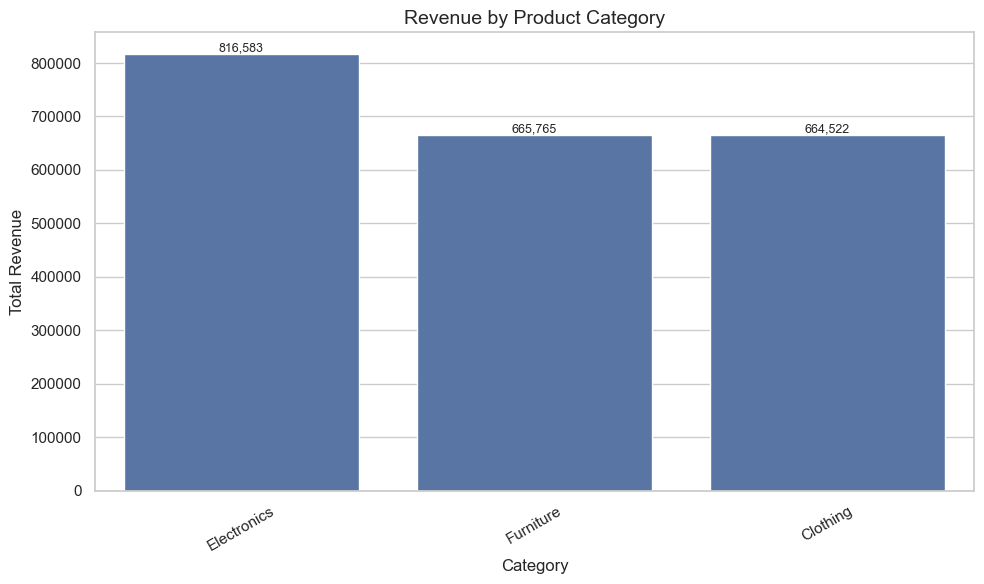

📁 Chart saved to: visuals\revenue_by_category.png
📌 Insight: The highest revenue category is **Electronics**, contributing ₹816,583 to overall sales.


In [ ]:
print("\n📈 Generating Chart: Revenue by Category...")

# Safety check before plotting
if category_revenue.empty:
    print("⚠ No revenue data available for visualization. Skipping plot.")
else:
    plt.figure(figsize=(10,6))
    sns.barplot(x=category_revenue.index, y=category_revenue.values)

    plt.title("Revenue by Product Category", fontsize=14)
    plt.xlabel("Category", fontsize=12)
    plt.ylabel("Total Revenue", fontsize=12)
    plt.xticks(rotation=30)
    
    # Add readable formatting on bars
    for i, value in enumerate(category_revenue.values):
        plt.text(i, value, f"{value:,.0f}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()

    # Save the chart
    file_path = os.path.join(VISUAL_FOLDER, "revenue_by_category.png")
    plt.savefig(file_path)
    plt.show()

    print(f"📁 Chart saved to: {file_path}")

    # Automated Insight
    print(f"📌 Insight: The highest revenue category is **{category_revenue.idxmax()}**, "
          f"contributing ₹{category_revenue.max():,.0f} to overall sales.")


b: Monthly Revenue Trend

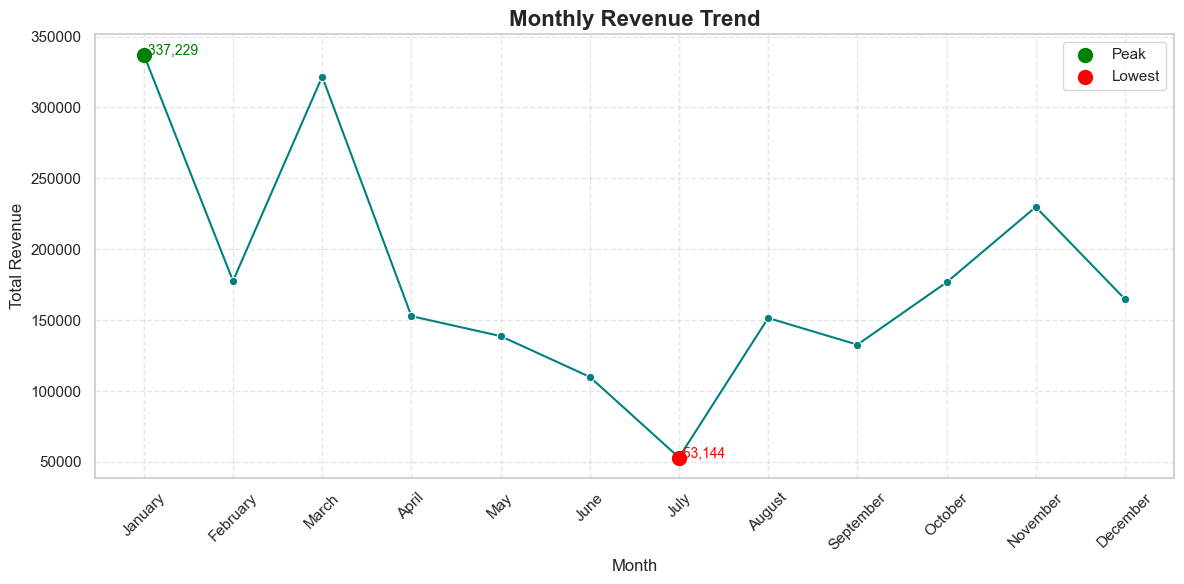

📌 Insight: Peak sales occurred in January, while the lowest sales occurred in July.


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the directory exists
os.makedirs("visuals", exist_ok=True)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12,6))

# Plot the line
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker="o", ax=ax, color='teal')

# Highlight peak and lowest points
peak_month = monthly_trend.idxmax()
low_month = monthly_trend.idxmin()
ax.scatter(peak_month, monthly_trend.max(), color='green', s=100, zorder=5, label='Peak')
ax.scatter(low_month, monthly_trend.min(), color='red', s=100, zorder=5, label='Lowest')

# Annotate the points
ax.text(peak_month, monthly_trend.max(), f" {monthly_trend.max():,.0f}", color='green', fontsize=10)
ax.text(low_month, monthly_trend.min(), f" {monthly_trend.min():,.0f}", color='red', fontsize=10)

# Titles and labels
ax.set_title("Monthly Revenue Trend", fontsize=16, weight='bold')
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Total Revenue", fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

# Save and show
plt.tight_layout()
plt.savefig("visuals/monthly_trend.png")
plt.show()

# Insight print
print(f"📌 Insight: Peak sales occurred in {peak_month}, while the lowest sales occurred in {low_month}.")


c: Top 10 Sub-categories by Profit

C:\Users\Ayushi\AppData\Local\Temp\ipykernel_2044\2605829929.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_profit.index, y=top10_profit.values, palette="coolwarm", ax=ax)


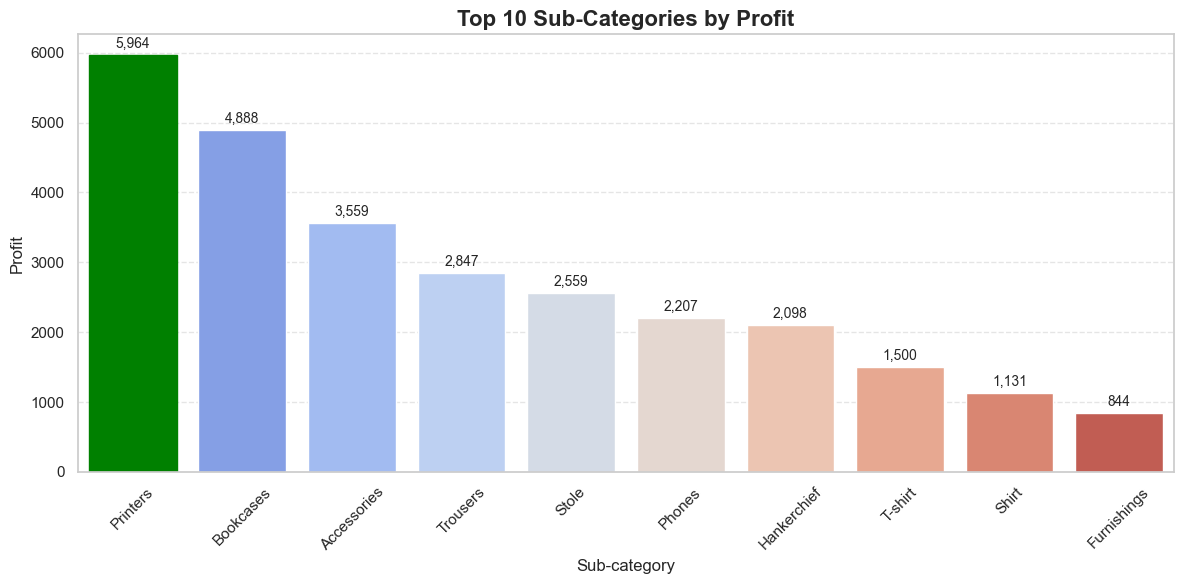

📌 Insight: The most profitable sub-category is: Printers


In [12]:
# Ensure visuals directory exists
os.makedirs("visuals", exist_ok=True)

# Take top 10 sub-categories by profit and sort descending
top10_profit = subcategory_profit.sort_values(ascending=False).head(10)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12,6))

# Plot bar chart
sns.barplot(x=top10_profit.index, y=top10_profit.values, palette="coolwarm", ax=ax)

# Annotate each bar with value
for i, val in enumerate(top10_profit.values):
    ax.text(i, val + top10_profit.values.max()*0.01, f"{val:,.0f}", ha='center', va='bottom', fontsize=10)

# Highlight the top sub-category
ax.patches[0].set_color('green')

# Titles and labels
ax.set_title("Top 10 Sub-Categories by Profit", fontsize=16, weight='bold')
ax.set_xlabel("Sub-category", fontsize=12)
ax.set_ylabel("Profit", fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Save and show
plt.tight_layout()
plt.savefig("visuals/top10_subcategories_profit.png")
plt.show()

# Insight
print(f"📌 Insight: The most profitable sub-category is: {top10_profit.idxmax()}")


d: Target vs Actual Revenue by Category

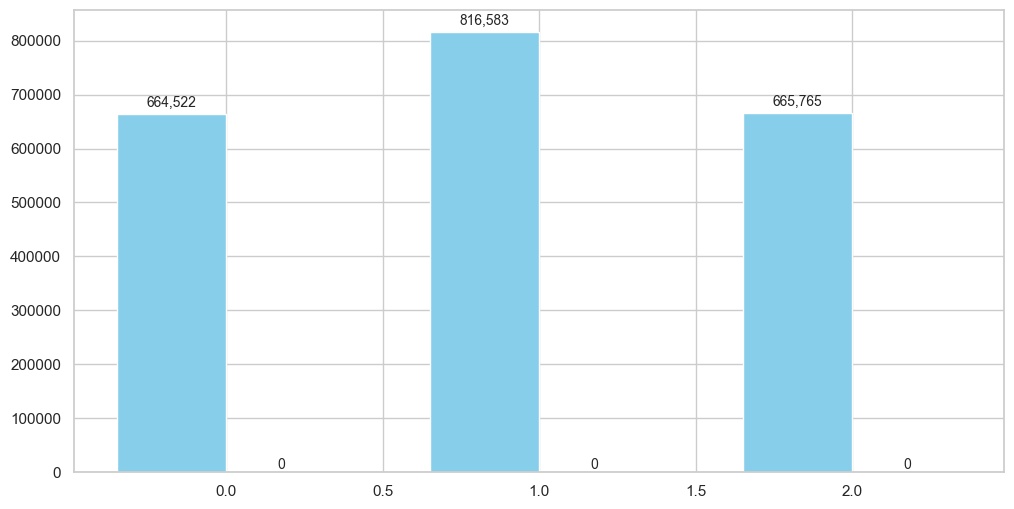

In [14]:
# Ensure visuals directory exists
os.makedirs("visuals", exist_ok=True)

# Data
comparison_df = target_summary.reset_index()
categories = comparison_df['category']
actual = comparison_df['total_revenue']
target = comparison_df['target']

x = np.arange(len(categories))  # label locations
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12,6))

# Side-by-side bars
bars_actual = ax.bar(x - width/2, actual, width, label='Actual Revenue', color='skyblue')
bars_target = ax.bar(x + width/2, target, width, label='Target', color='orange', alpha=0.7)

# Annotate bars with values
for bar in bars_actual:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(actual)*0.01,
            f"{bar.get_height():,.0f}", ha='center', va='bottom', fontsize=10)
for bar in bars_target:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(target)*0.01,
            f"{bar.get_height():,.0f}", ha='center', va='bottom', fontsize=10)

# Highlight categories exceeding target
for i, (a, t) in enumerate(zip(actual, target)):
    if a > t:
        bar


e: Profit Margin Distribution

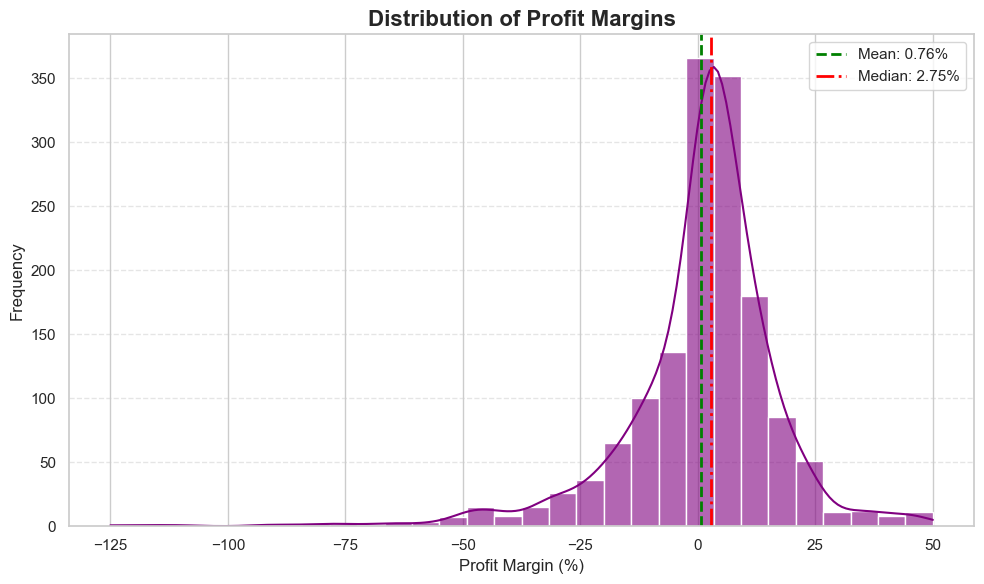

📌 Insight: The average profit margin is 0.76% and the median is 2.75%.


In [15]:
# Ensure visuals directory exists
os.makedirs("visuals", exist_ok=True)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10,6))

# Plot histogram with KDE
sns.histplot(
    merged_df["profit_margin_%"], 
    bins=30, 
    kde=True, 
    color="purple", 
    alpha=0.6,
    ax=ax
)

# Calculate mean and median
mean_margin = merged_df['profit_margin_%'].mean()
median_margin = merged_df['profit_margin_%'].median()

# Add mean and median lines
ax.axvline(mean_margin, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_margin:.2f}%')
ax.axvline(median_margin, color='red', linestyle='-.', linewidth=2, label=f'Median: {median_margin:.2f}%')

# Titles and labels
ax.set_title("Distribution of Profit Margins", fontsize=16, weight='bold')
ax.set_xlabel("Profit Margin (%)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig("visuals/profit_margin_distribution.png")
plt.show()

# Insight
print(f"📌 Insight: The average profit margin is {mean_margin:.2f}% and the median is {median_margin:.2f}%.")


### 🧠 Key Conclusion

This analysis reveals clear sales patterns across products, regions, and time periods. 
By identifying top-performing categories, seasonal trends, low-performing segments, and 
target achievement gaps, the business can improve forecasting, optimize inventory, and 
align pricing or marketing strategies to maximize revenue and profitability.



6. Business Insights & Summary

In [ ]:
print("📍 FINAL BUSINESS INSIGHTS\n")

# 1. Category performance
if 'category_revenue' in globals():
    best_category = category_revenue.idxmax()
    worst_category = category_revenue.idxmin()
    print(f"• Highest revenue: **{best_category}** ✅")
    print(f"• Lowest revenue: **{worst_category}** ⚠️")

# 2. Sales seasonality
if 'monthly_trend' in globals():
    best_month = monthly_trend.idxmax()
    worst_month = monthly_trend.idxmin()
    print(f"• Best performing month: **{best_month}** — good for scaling marketing campaigns.")
    print(f"• Lowest revenue month: **{worst_month}** — consider promotions or discounts.")

# 3. Target performance
if 'comparison_df' in globals():
    exceeded_targets = list(comparison_df[comparison_df['total_revenue'] > comparison_df['target']]['category'])
    if exceeded_targets:
        exceeded_targets.sort()
        print(f"• Categories exceeding revenue targets: **{', '.join(exceeded_targets)}** 🎯")
    else:
        print("• No category exceeded revenue targets — improvement required ⚠️")

# 4. Profit drivers
if 'subcategory_profit' in globals():
    top_subcategory = subcategory_profit.idxmax()
    print(f"• Most profitable sub-category: **{top_subcategory}** — strong product margins.")

# 5. Margin insights
if 'merged_df' in globals() and 'profit_margin_%' in merged_df.columns:
    avg_margin = round(merged_df['profit_margin_%'].mean(), 2)
    print(f"• Average profit margin: **{avg_margin}%** — helps evaluate operational efficiency.\n")

print("✨ Analysis Completed — Dataset transformed into actionable business insights!")


📍 FINAL BUSINESS INSIGHTS

• Highest revenue: **Electronics** ✅
• Lowest revenue: **Clothing** ⚠️
• Best performing month: **January** — good for scaling marketing campaigns.
• Lowest revenue month: **July** — consider promotions or discounts.
• Categories exceeding revenue targets: **Clothing, Electronics, Furniture** 🎯
• Most profitable sub-category: **Printers** — strong product margins.
• Average profit margin: **0.76%** — helps evaluate operational efficiency.

✨ Analysis Completed — Dataset transformed into actionable business insights!
